In [1]:
import numpy as np                                  # numerical arrays and operations
import sympy as sp                                  # symbolic math engine
from sympy.physics.mechanics import *               # ReferenceFrame, Point, Lagrangian, etc.
import scipy.linalg as la                           # eigenvalues, linear solvers
from scipy.integrate import solve_ivp               # Runge-Kutta ODE integrator
import matplotlib.pyplot as plt                     # 2D plotting
init_vprinting()                                    # render SymPy output as LaTeX in notebook

In [2]:
theta, psi = dynamicsymbols('theta psi')             # DOFs: nacelle tilt theta and rotor azimuth psi
t     = sp.symbols('t')                              # independent time variable
Omega = sp.Symbol('Omega', real=True, positive=True) # symbolic steady-state rotor speed

m_n, m_b         = sp.symbols('m_n m_b')             # nacelle and blade masses
k_t, c_t, g      = sp.symbols('k_t c_t g')           # tower stiffness, damping, gravity
X_n, Z_n         = sp.symbols('X_n Z_n')             # nacelle COM position in tower frame
X_h, Z_h         = sp.symbols('X_h Z_h')             # hub location in tower frame
Z_b               = sp.symbols('Z_b')                 # blade COM radial offset in rotor frame
J_xx_n, J_yy_n, J_zz_n = sp.symbols('J_xx_n J_yy_n J_zz_n')  # nacelle inertia components
J_xx_b, J_yy_b, J_zz_b = sp.symbols('J_xx_b J_yy_b J_zz_b')  # blade inertia components

In [3]:
N = ReferenceFrame('N')                              # inertial ground frame
T = N.orientnew('T', 'Axis', [theta, N.y])           # tower/nacelle frame: tilts about N.y
R = T.orientnew('R', 'Axis', [psi,   T.x])           # rotor frame: spins about T.x

O    = Point('O')                                     # fixed reference point at tower top
NCOM = O.locatenew('NCOM', X_n*T.x + Z_n*T.z)        # nacelle COM position
Hub  = O.locatenew('Hub',  X_h*T.x + Z_h*T.z)        # hub center position
BCOM = Hub.locatenew('BCOM', Z_b*R.z)                 # blade COM position in rotor frame

O.set_vel(N, 0)                                       # tower top is fixed in inertial frame
NCOM.v2pt_theory(O,   N, T)                           # nacelle COM velocity via two-point theorem
Hub.v2pt_theory(O,    N, T)                           # hub velocity via two-point theorem
BCOM.v2pt_theory(Hub, N, R)                           # blade COM velocity via two-point theorem

In [4]:
J_nac   = inertia(T, J_xx_n, J_yy_n, J_zz_n)        # nacelle inertia dyadic in tower frame
J_blade = inertia(R, J_xx_b, J_yy_b, J_zz_b)         # blade inertia dyadic in rotor frame

Nacelle = RigidBody('Nacelle', NCOM, T, m_n, (J_nac,   NCOM))  # nacelle rigid body
Blade   = RigidBody('Blade',   BCOM, R, m_b, (J_blade, BCOM))  # blade rigid body

In [5]:
Nacelle.potential_energy = (m_n*g*NCOM.pos_from(O).dot(N.z)    # nacelle gravitational PE
                            + sp.Rational(1,2)*k_t*theta**2)    # tower torsional spring PE
Blade.potential_energy   = m_b*g*BCOM.pos_from(O).dot(N.z)     # blade gravitational PE

damping = [(T, -c_t*theta.diff(t)*N.y)]                         # viscous tower damping torque

Lagrangian


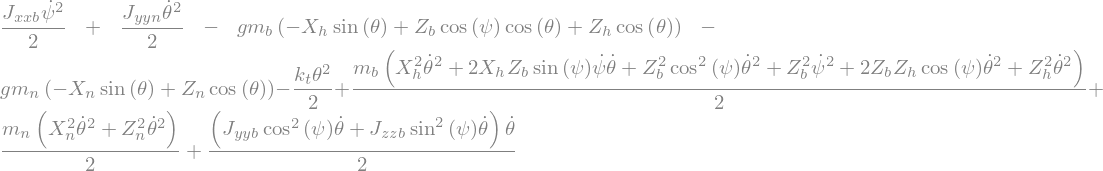

Equations of Motion


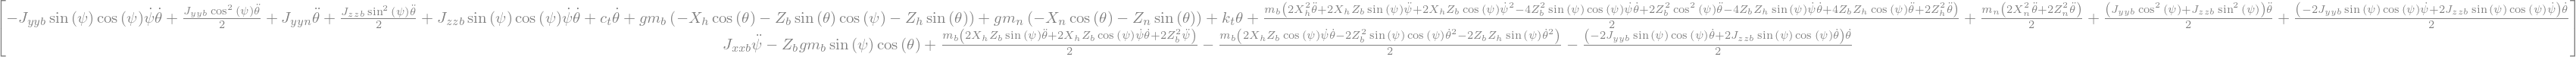

In [17]:
L   = Lagrangian(N, Nacelle, Blade)    
print("Lagrangian")              # T - V system Lagrangian
display(L)                                            # show symbolic Lagrangian
LM  = LagrangesMethod(L, [theta, psi], frame=N, forcelist=damping)  # Lagrange method with damping
eom = LM.form_lagranges_equations()      
print("Equations of Motion")             # derive 2-DOF equations of motion
display(eom)                                            # show symbolic equations of motion

Mass Matrix M:


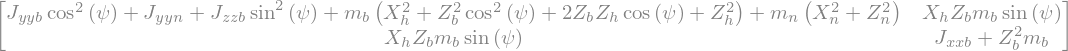

Forcing Vector F:


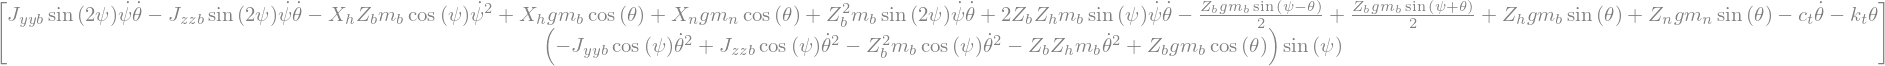

In [7]:
M = sp.simplify(sp.trigsimp(LM.mass_matrix))         # symbolic mass matrix M(q)
F = sp.simplify(sp.trigsimp(LM.forcing))              # symbolic forcing vector F(q, qdot)
print("Mass Matrix M:")
display(M)
print("Forcing Vector F:")
display(F)

## Nonlinear Simulation

In [8]:
params = {
    m_n: 50000,                                       # nacelle mass [kg]
    m_b: 10000,                                       # blade mass [kg]
    X_n: -1.5,                                        # nacelle COM x-offset [m]
    Z_n:  2.0,                                        # nacelle COM z-offset [m]
    X_h: -2.0,                                        # hub x-offset [m]
    Z_h:  3.0,                                        # hub z-offset [m]
    Z_b:  1.5,                                        # blade COM radial offset [m]
    k_t:  1e7,                                        # tower torsional stiffness [N.m/rad]
    c_t:  5e5,                                        # tower torsional damping [N.m.s/rad]
    g:    9.81,                                       # gravitational acceleration [m/s^2]
    J_xx_n: 1e6, J_yy_n: 5e6, J_zz_n: 1e6,          # nacelle inertia components [kg.m^2]
    J_xx_b: 1e5, J_yy_b: 1e6, J_zz_b: 1e6,          # blade inertia components [kg.m^2]
}
OMEGA_VAL = 1.5                                       # operating rotor speed [rad/s]

In [9]:
q_sym     = [theta, psi]                             # generalized coordinates
dq_sym    = [theta.diff(t), psi.diff(t)]             # generalized velocities
state_vec = q_sym + dq_sym                           # full state: [theta, psi, theta_dot, psi_dot]

M_func = sp.lambdify((state_vec,), M.subs(params), 'numpy')  # numerical mass matrix callable
F_func = sp.lambdify((state_vec,), F.subs(params), 'numpy')  # numerical forcing vector callable

def system_dynamics(t, y):
    M_num  = M_func(y)                               # mass matrix at current state
    F_num  = F_func(y).flatten()                     # forcing vector at current state
    accels = la.solve(M_num, F_num)                  # solve M*q_ddot = F for accelerations
    return [y[2], y[3], accels[0], accels[1]]        # return [theta_dot, psi_dot, theta_ddot, psi_ddot]

In [10]:
t_span = (0, 2000)                                   # simulation window [s]
t_eval = np.linspace(*t_span, 1000)                  # output time grid
y0     = [np.deg2rad(5), 0, 0, OMEGA_VAL]            # IC: [5 deg tilt, 0 azimuth, 0 tilt rate, Omega]

sol = solve_ivp(system_dynamics, t_span, y0, t_eval=t_eval, method='RK45')  # RK45 integration
print('Simulation complete.')

Simulation complete.


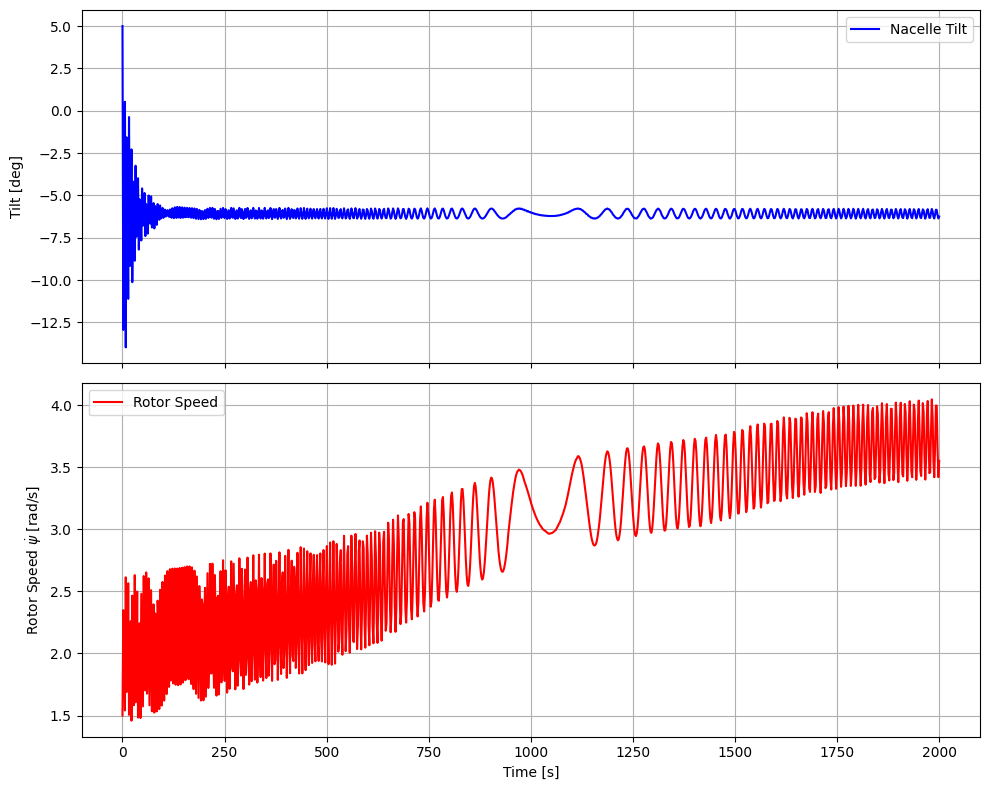

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)  # two-panel figure

ax1.plot(sol.t, np.rad2deg(sol.y[0]), 'b', label='Nacelle Tilt')     # tilt in degrees
ax1.set_ylabel('Tilt [deg]')
ax1.legend(); ax1.grid(True)

ax2.plot(sol.t, sol.y[3], 'r', label='Rotor Speed')                  # speed in rad/s
ax2.set_ylabel('Rotor Speed $\\dot{\\psi}$ [rad/s]')
ax2.set_xlabel('Time [s]')
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

## Linearization

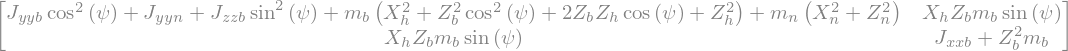

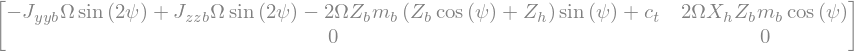

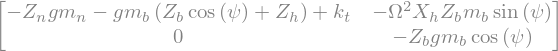

In [12]:
op_point = {
    theta:            0,       # linearize at zero tilt
    theta.diff(t):    0,       # zero tilt rate at equilibrium
    theta.diff(t, 2): 0,       # zero tilt acceleration at equilibrium
    psi.diff(t):      Omega,   # steady-state rotor speed
    psi.diff(t, 2):   0,       # zero rotor acceleration at equilibrium
}

q_vec  = sp.Matrix([theta, psi])                     # coordinate column vector
dq_vec = q_vec.diff(t)                               # velocity column vector

M_lin = sp.simplify(LM.mass_matrix.subs(op_point))   # linearized mass matrix
f_vec = LM.forcing                                    # symbolic forcing vector
C_lin = sp.simplify(-f_vec.jacobian(dq_vec).subs(op_point))  # damping / gyroscopic matrix
K_lin = sp.simplify(-f_vec.jacobian(q_vec).subs(op_point))   # stiffness / centrifugal matrix

display(M_lin); display(C_lin); display(K_lin)

## Eigenvalue Analysis

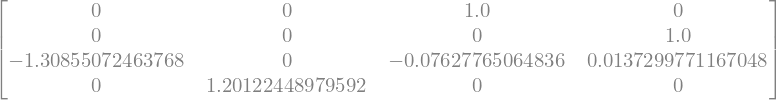

Operating Speed: Omega = 1.5 rad/s

Mode 1: lambda=-0.0381+1.1433j  wn=0.1821 Hz  zeta=0.0333
Mode 2: lambda=-1.0960+0.0000j  wn=0.1744 Hz  zeta=1.0000
Mode 2: lambda=1.0960+0.0000j  wn=0.1744 Hz  zeta=-1.0000


In [13]:
M_sym, A_sym, _, _ = LM.linearize(                  # extract un-inverted linearized matrices
    q_ind=[theta, psi],
    qd_ind=[theta.diff(t), psi.diff(t)],
    op_point=op_point
)

subs_dict = {**params, psi: 0, Omega: OMEGA_VAL}     # physical params + operating point values
M_sub = M_sym.subs(subs_dict)                        # substitute into mass matrix
A_sub = A_sym.subs(subs_dict)                        # substitute into uninverted A matrix

A_ss  = sp.expand(M_sub.inv() * A_sub).evalf()       # state-space A = M^-1 * A_uninv
display(A_ss)

A_num = np.array(A_ss.tolist(), dtype=np.float64)    # convert to NumPy for eigenanalysis
eigenvalues, _ = la.eig(A_num)                       # compute eigenvalues

print(f'Operating Speed: Omega = {OMEGA_VAL} rad/s\n')
for i, lam in enumerate(eigenvalues):
    if np.abs(lam) > 1e-4 and np.imag(lam) >= 0:     # skip near-zero and conjugate duplicates
        wn   = np.abs(lam)                            # natural frequency [rad/s]
        zeta = -np.real(lam) / wn                     # damping ratio
        print(f'Mode {i//2+1}: lambda={lam:.4f}  wn={wn/(2*np.pi):.4f} Hz  zeta={zeta:.4f}')

## Linearized Simulation

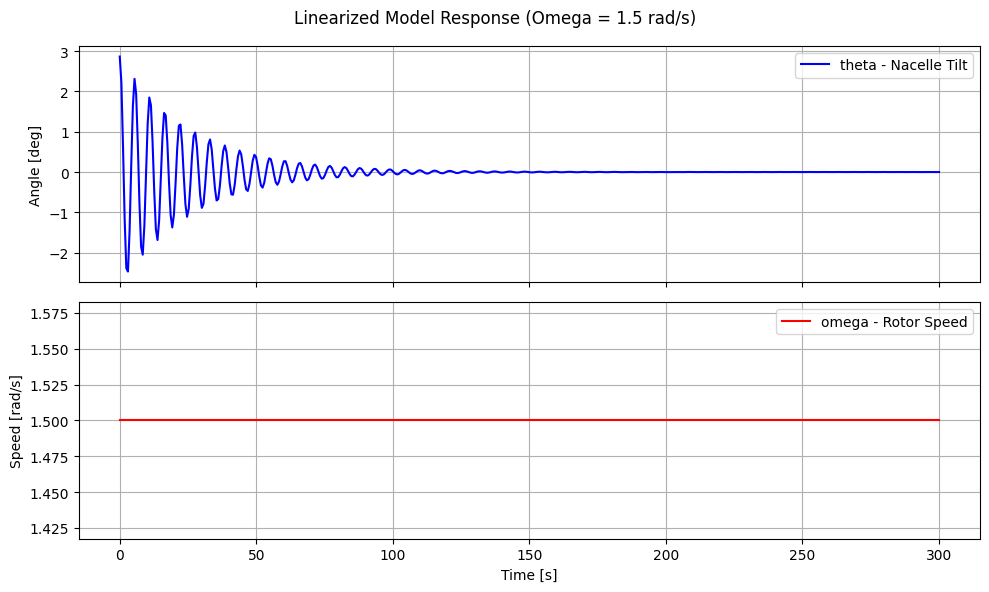

In [14]:
def lin_dynamics(t, x):
    return A_num @ x                                  # linear state-space: x_dot = A*x

x0     = np.array([0.05, 0.0, 0.0, 0.0])             # 0.05 rad initial tilt perturbation
t_span = (0, 300)
t_eval = np.linspace(*t_span, 500)

sol_lin = solve_ivp(lin_dynamics, t_span, x0, t_eval=t_eval, method='RK45')  # integrate linear model

theta_abs   = sol_lin.y[0]                            # tilt perturbation (op-point = 0, so delta_theta = theta)
psi_dot_abs = OMEGA_VAL + sol_lin.y[3]               # absolute rotor speed: Omega + delta_psi_dot

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(sol_lin.t, np.rad2deg(theta_abs), 'b', label='theta - Nacelle Tilt')
axs[0].set_ylabel('Angle [deg]'); axs[0].legend(); axs[0].grid(True)

axs[1].plot(sol_lin.t, psi_dot_abs, 'r', label='omega - Rotor Speed')
axs[1].set_ylabel('Speed [rad/s]'); axs[1].set_xlabel('Time [s]')
axs[1].legend(); axs[1].grid(True)

plt.suptitle(f'Linearized Model Response (Omega = {OMEGA_VAL} rad/s)')
plt.tight_layout(); plt.show()

## Validate Linearization against Nonlinear Model

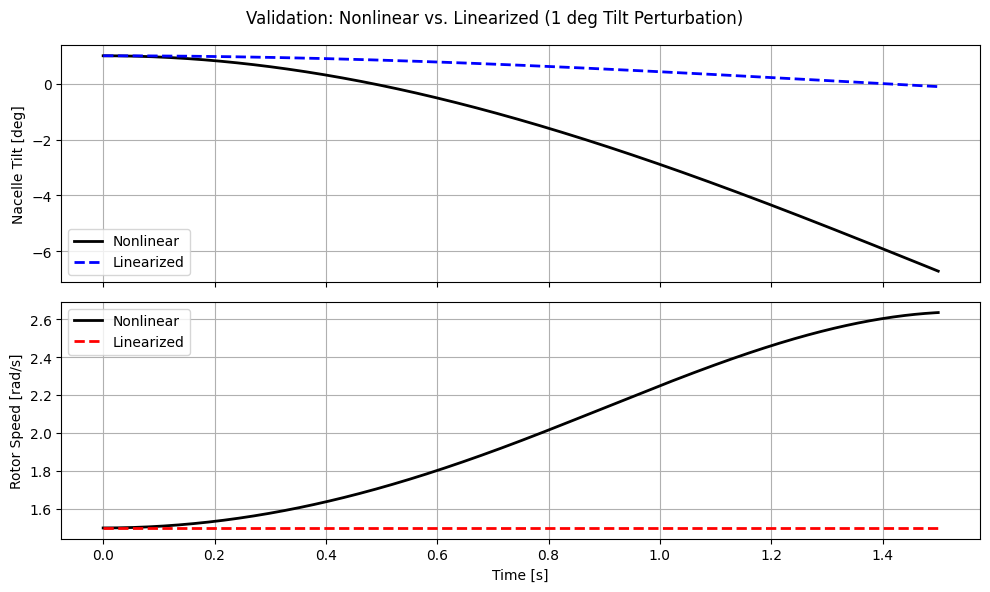

In [15]:
theta_pert = np.deg2rad(1.0)                         # 1 degree tilt perturbation
init_nl    = [theta_pert, 0.0, 0.0, OMEGA_VAL]       # nonlinear ICs: absolute states
init_lin   = [theta_pert, 0.0, 0.0, 0.0]             # linear ICs: perturbations from equilibrium

t_span = (0, 1.5)                                     # short window to isolate transient
t_eval = np.linspace(*t_span, 500)

sol_nl  = solve_ivp(system_dynamics, t_span, init_nl,  t_eval=t_eval, method='RK45')  # nonlinear
sol_lin = solve_ivp(lin_dynamics,    t_span, init_lin, t_eval=t_eval, method='RK45')  # linearized

theta_nl_deg  = np.rad2deg(sol_nl.y[0])               # nonlinear tilt [deg]
theta_lin_deg = np.rad2deg(sol_lin.y[0])              # linear tilt perturbation [deg]
psi_d_nl      = sol_nl.y[3]                           # nonlinear rotor speed [rad/s]
psi_d_lin     = OMEGA_VAL + sol_lin.y[3]             # linear absolute rotor speed [rad/s]

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(sol_nl.t,  theta_nl_deg,  'k-',  lw=2, label='Nonlinear')
axs[0].plot(sol_lin.t, theta_lin_deg, 'b--', lw=2, label='Linearized')
axs[0].set_ylabel('Nacelle Tilt [deg]'); axs[0].legend(); axs[0].grid(True)

axs[1].plot(sol_nl.t,  psi_d_nl,  'k-',  lw=2, label='Nonlinear')
axs[1].plot(sol_lin.t, psi_d_lin, 'r--', lw=2, label='Linearized')
axs[1].set_ylabel('Rotor Speed [rad/s]'); axs[1].set_xlabel('Time [s]')
axs[1].legend(); axs[1].grid(True)

plt.suptitle('Validation: Nonlinear vs. Linearized (1 deg Tilt Perturbation)')
plt.tight_layout(); plt.show()